In [56]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../Data/hotel_bookings_cleaned.csv")

df.head()

,hotel,is_canceled,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time,total_nights,total_guests,planner_type,season
0,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,0.0,0,0,Check-Out,01-07-2015,342,0,2.0,Early Planner,Summer
1,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,0.0,0,0,Check-Out,01-07-2015,737,0,2.0,Early Planner,Summer
2,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Direct,...,75.0,0,0,Check-Out,02-07-2015,7,1,1.0,Last Minute,Summer
3,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Corporate,...,75.0,0,0,Check-Out,02-07-2015,13,1,1.0,Medium Planner,Summer
4,Resort Hotel,0,2015,July,0,2,2,0.0,GBR,Online TA,...,98.0,0,1,Check-Out,03-07-2015,14,2,2.0,Medium Planner,Summer


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84224 entries, 0 to 84223
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84224 non-null  str    
 1   is_canceled                     84224 non-null  int64  
 2   arrival_date_year               84224 non-null  int64  
 3   arrival_date_month              84224 non-null  str    
 4   stays_in_weekend_nights         84224 non-null  int64  
 5   stays_in_week_nights            84224 non-null  int64  
 6   adults                          84224 non-null  int64  
 7   children                        84224 non-null  float64
 8   country                         84224 non-null  str    
 9   market_segment                  84224 non-null  str    
 10  is_repeated_guest               84224 non-null  int64  
 11  previous_cancellations          84224 non-null  int64  
 12  previous_bookings_not_canceled  84224 non-n

In [58]:
y = df["is_canceled"]

X = df.drop("is_canceled", axis=1)

In [59]:
label_encoder = LabelEncoder()

categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    X[col] = label_encoder.fit_transform(X[col].astype(str))

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_6620\60842550.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [60]:
scaler = StandardScaler()

numeric_columns = X.select_dtypes(include=["int64","float64"]).columns

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

X.head()

,hotel,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,is_repeated_guest,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time,total_nights,total_guests,planner_type,season
0,1.287438,-1.751537,-0.104252,-0.975114,-1.278195,0.207630,-0.283498,1.087368,-1.556486,-0.204031,...,-2.262758,-0.293304,-0.839395,0.543347,-1.686603,3.026459,-1.315461,0.015954,-1.003431,0.51282
1,1.287438,-1.751537,-0.104252,-0.975114,-1.278195,0.207630,-0.283498,1.087368,-1.556486,-0.204031,...,-2.262758,-0.293304,-0.839395,0.543347,-1.686603,7.595812,-1.315461,0.015954,-1.003431,0.51282
2,1.287438,-1.751537,-0.104252,-0.975114,-0.789888,-1.386051,-0.283498,-0.622429,-1.556486,-0.204031,...,-0.599465,-0.293304,-0.839395,0.543347,-1.570206,-0.848815,-0.952230,-1.305293,0.130667,0.51282
3,1.287438,-1.751537,-0.104252,-0.975114,-0.789888,-1.386051,-0.283498,-0.622429,-2.303845,-0.204031,...,-0.599465,-0.293304,-0.839395,0.543347,-1.570206,-0.779407,-0.952230,-1.305293,1.264765,0.51282
4,1.287438,-1.751537,-0.104252,-0.975114,-0.301580,0.207630,-0.283498,-0.622429,0.685591,-0.204031,...,-0.089389,-0.293304,0.368526,0.543347,-1.457565,-0.767839,-0.588999,0.015954,1.264765,0.51282


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(67379, 27)
(16845, 27)


In [62]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [63]:
print(y_pred_log[:20])

[0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1]


In [64]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

tree_model.fit(X_train,y_train)

y_pred_tree = tree_model.predict(X_test)

y_prob_tree = tree_model.predict_proba(X_test)[:,1]

In [65]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test,y_pred_log)

tree_acc = accuracy_score(y_test,y_pred_tree)

print("Logistic Regression Accuracy :",log_acc)

print("Decision Tree Accuracy :",tree_acc)

Logistic Regression Accuracy : 0.988780053428317
Decision Tree Accuracy : 1.0


In [66]:
results = pd.DataFrame({

    "Actual Value":y_test,

    "Predicted Value":y_pred_log,

    "Prediction Probability":y_prob_log

})

results.head()

,Actual Value,Predicted Value,Prediction Probability
27667,0,0,0.030046
25013,0,0,0.023520
37227,1,1,0.959685
77125,0,0,0.074764
23631,0,0,0.021489


In [67]:
results.to_csv(
    "../outputs/model_results.csv",
    index=False
)

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("----- Logistic Regression -----")

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

print("\n")
print("----- Decision Tree -----")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

----- Logistic Regression -----
Accuracy : 0.988780053428317
Precision: 1.0
Recall   : 0.9589130434782609
F1 Score : 0.9790256353345911


----- Decision Tree -----
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


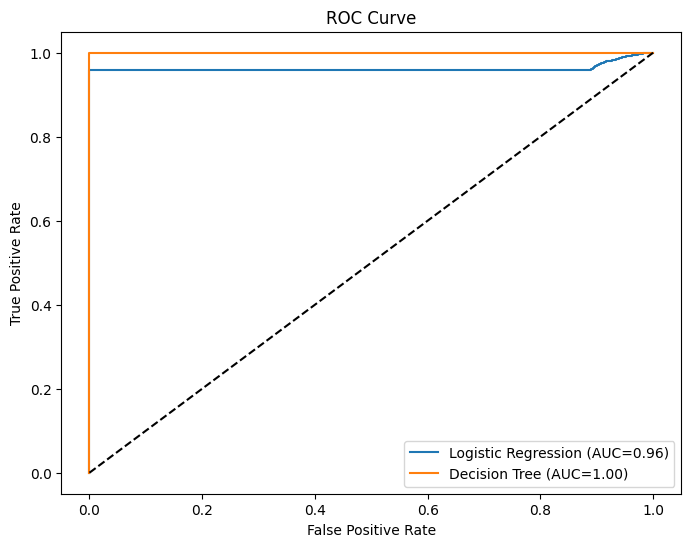

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)


fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={auc_tree:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

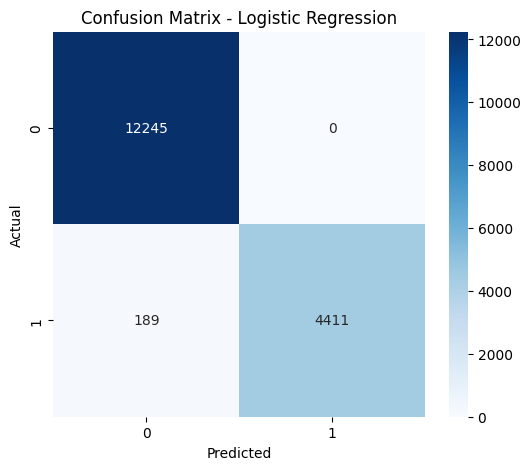

In [70]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [71]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     12245
           1       1.00      0.96      0.98      4600

    accuracy                           0.99     16845
   macro avg       0.99      0.98      0.99     16845
weighted avg       0.99      0.99      0.99     16845



In [72]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": tree_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
20,reservation_status,1.0
1,arrival_date_year,0.0
0,hotel,0.0
3,stays_in_weekend_nights,0.0
4,stays_in_week_nights,0.0
5,adults,0.0
6,children,0.0
7,country,0.0
8,market_segment,0.0
9,is_repeated_guest,0.0


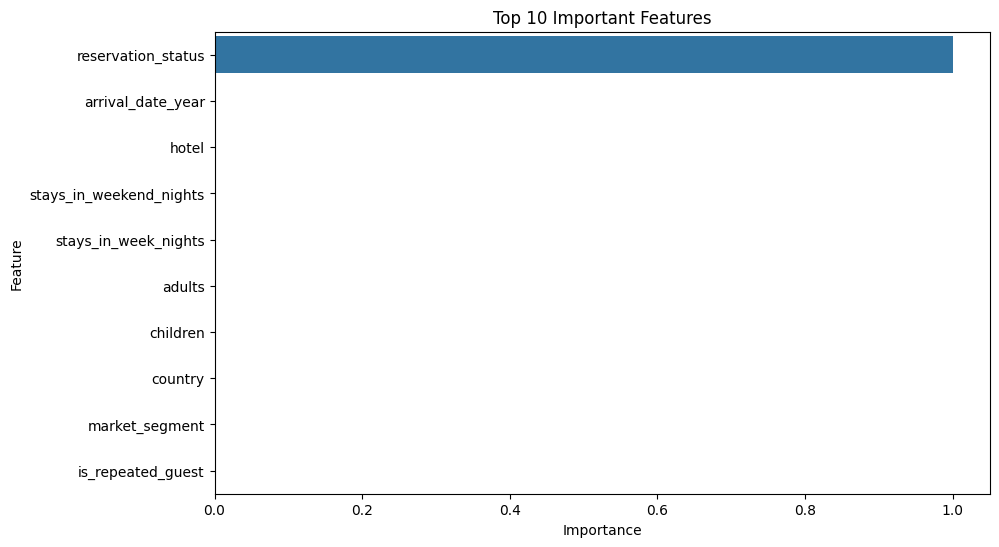

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [74]:
coef = pd.DataFrame({

    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]

})

coef["Absolute"] = coef["Coefficient"].abs()

coef = coef.sort_values(
    by="Absolute",
    ascending=False
)

coef.head(10)

,Feature,Coefficient,Absolute
20,reservation_status,-2.794295,2.794295
18,required_car_parking_spaces,-1.629234,1.629234
7,country,0.390302,0.390302
13,assigned_room_type,-0.260623,0.260623
12,reserved_room_type,0.236330,0.236330
19,total_of_special_requests,-0.215559,0.215559
8,market_segment,0.173487,0.173487
0,hotel,-0.165567,0.165567
15,deposit_type,0.128133,0.128133
22,lead_time,0.112939,0.112939


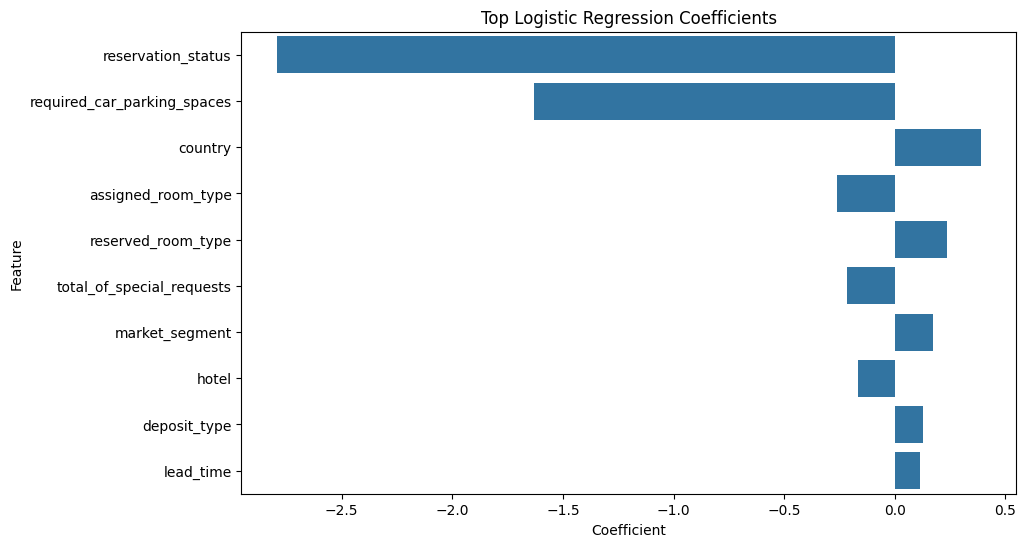

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")

plt.show()